您可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和 [Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購 *Think Python 3e* 的印刷版和電子書版本。

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

# 繼承

最常與物件導向程式設計相關聯的語言特性是**繼承**。
繼承是定義新類別的能力，該類別是現有類別的修改版本。
在本章中，我將使用代表撲克牌、牌組和撲克牌型的類別來示範繼承。
如果您不玩撲克，不用擔心 -- 我會告訴您需要知道的內容。

## 表示撲克牌

標準牌組中有 52 張撲克牌 -- 每一張都屬於四種花色之一和十三種點數之一。
花色是黑桃、紅心、方塊和梅花。
點數是 A、2、3、4、5、6、7、8、9、10、J、Q 和 K。
根據您玩的遊戲，A 可能比 K 大或比 2 小。

如果我們想要定義一個新物件來表示撲克牌，很明顯屬性應該是什麼：`rank` 和 `suit`。
屬性應該是什麼類型就不那麼明顯了。
一種可能性是對花色使用像 `'Spade'` 這樣的字串，對點數使用像 `'Queen'` 這樣的字串。
這種實作的問題是不容易比較撲克牌來看哪張的點數或花色較高。

另一種選擇是使用整數來**編碼**點數和花色。
在這個背景下，「編碼」意味著我們要定義數字與花色之間的對應，或者數字與點數之間的對應。
這種編碼不是要保密的（那會是「加密」）。

例如，這個表格顯示花色和對應的整數代碼：

| 花色 | 代碼 |
| --- | --- |
|  黑桃     |   3  |
|  紅心     |   2  |
|  方塊   |   1  |
|  梅花      |   0  |

有了這種編碼，我們可以通過比較代碼來比較花色。

為了編碼點數，我們將使用整數 `2` 來表示點數 `2`，`3` 來表示 `3`，以此類推直到 `10`。
下面的表格顯示了人頭牌的代碼。

| 點數 | 代碼 |
| --- | --- |
|  J     |   11  |
|  Q   |   12  |
|  K      |   13  |

我們可以使用 `1` 或 `14` 來表示 A，取決於我們希望它被認為比其他點數低還是高。

為了表示這些編碼，我們將使用兩個字串清單，一個包含花色的名稱，另一個包含點數的名稱。

這裡是表示撲克牌的類別定義，這些字串清單作為**類別變數**，它們是在類別定義內但不在方法內定義的變數。

In [2]:
class Card:
    """Represents a standard playing card."""

    suit_names = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
    rank_names = [None, 'Ace', '2', '3', '4', '5', '6', '7', 
                  '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']

`rank_names` 的第一個元素是 `None`，因為沒有點數為零的牌。通過包含 `None` 作為佔位符，我們得到一個具有良好特性的清單，索引 `2` 對應到字串 `'2'`，以此類推。

類別變數與類別相關聯，而不是與類別的實例相關聯，所以我們可以這樣存取它們。

In [3]:
Card.suit_names

['Clubs', 'Diamonds', 'Hearts', 'Spades']

我們可以使用 `suit_names` 來查找花色並取得對應的字串。

In [4]:
Card.suit_names[0]

'Clubs'

以及 `rank_names` 來查找點數。

In [5]:
Card.rank_names[11]

'Jack'

## 撲克牌屬性

這裡是 `Card` 類別的 `__init__` 方法 -- 它接受 `suit` 和 `rank` 作為參數並將它們指派給同名的屬性。

In [6]:
%%add_method_to Card

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

現在我們可以像這樣創建一個 `Card` 物件。

In [7]:
queen = Card(1, 12)

我們可以使用新實例來存取屬性。

In [8]:
queen.suit, queen.rank

(1, 12)

使用實例來存取類別變數也是合法的。

In [9]:
queen.suit_names

['Clubs', 'Diamonds', 'Hearts', 'Spades']

但如果您使用類別，更清楚它們是類別變數，而不是屬性。

## 印出撲克牌

這裡是 `Card` 物件的 `__str__` 方法。

In [10]:
%%add_method_to Card

    def __str__(self):
        rank_name = Card.rank_names[self.rank]
        suit_name = Card.suit_names[self.suit]
        return f'{rank_name} of {suit_name}' 

當我們印出一個 `Card` 時，Python 呼叫 `__str__` 方法來取得物件的人類可讀表示。

In [11]:
print(queen)

Queen of Diamonds


下面是 `Card` 類別物件和 Card 實例的圖表。
`Card` 是一個類別物件，所以它的類型是 `type`。
`queen` 是 `Card` 的實例，所以它的類型是 `Card`。
為了節省空間，我沒有畫出 `suit_names` 和 `rank_names` 的內容。

In [12]:
from diagram import Binding, Value, Frame, Stack

bindings = [Binding(Value(name), draw_value=False)
            for name in ['suit_names', 'rank_names']]
    
frame1 = Frame(bindings, name='type', dy=-0.5, offsetx=0.77)
binding1 = Binding(Value('Card'), frame1)

bindings = [Binding(Value(name), Value(value))
            for name, value in zip(['suit', 'rank'], [1, 11])]
    
frame2 = Frame(bindings, name='Card', dy=-0.3, offsetx=0.33)
binding2 = Binding(Value('queen'), frame2)

stack = Stack([binding1, binding2], dy=-1.2)

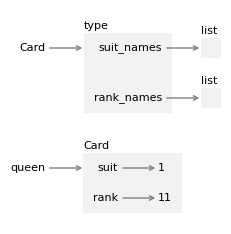

In [13]:
from diagram import diagram, Bbox, make_list, adjust

width, height, x, y = [2.11, 2.14, 0.35, 1.76]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)

value = make_list([])
bbox2 = value.draw(ax, x+1.66, y)

value = make_list([])
bbox3 = value.draw(ax, x+1.66, y-0.5)

bbox = Bbox.union([bbox, bbox2, bbox3])
#adjust(x, y, bbox)

每個 `Card` 實例都有自己的 `suit` 和 `rank` 屬性，但只有一個 `Card` 類別物件，而且類別變數 `suit_names` 和 `rank_names` 只有一份副本。

## 比較撲克牌

假設我們創建第二個具有相同花色和點數的 `Card` 物件。

In [14]:
queen2 = Card(1, 12)
print(queen2)

Queen of Diamonds


如果我們使用 `==` 運算子來比較它們，它檢查 `queen` 和 `queen2` 是否指向同一個物件。

In [15]:
queen == queen2

False

它們不是，所以回傳 `False`。
我們可以通過定義特殊方法 `__eq__` 來改變這種行為。

In [16]:
%%add_method_to Card

    def __eq__(self, other):
        return self.suit == other.suit and self.rank == other.rank

`__eq__` 接受兩個 `Card` 物件作為參數，如果它們有相同的花色和點數就回傳 `True`，即使它們不是同一個物件。
換句話說，它檢查它們是否等價，即使它們不是相同的。

當我們對 `Card` 物件使用 `==` 運算子時，Python 呼叫 `__eq__` 方法。

In [17]:
queen == queen2

True

作為第二個測試，讓我們創建一張具有相同花色但不同點數的牌。

In [18]:
six = Card(1, 6)
print(six)

6 of Diamonds


我們可以確認 `queen` 和 `six` 不等價。

In [19]:
queen == six

False

如果我們使用 `!=` 運算子，Python 調用一個稱為 `__ne__` 的特殊方法，如果它存在的話。
否則它調用 `__eq__` 並反轉結果 -- 所以如果 `__eq__` 回傳 `True`，`!=` 運算子的結果是 `False`。

In [20]:
queen != queen2

False

In [21]:
queen != six

True

現在假設我們想要比較兩張牌看哪張更大。
如果我們使用關係運算子之一，我們會得到一個 `TypeError`。

In [22]:
%%expect TypeError

queen < queen2

TypeError: '<' not supported between instances of 'Card' and 'Card'

為了改變 `<` 運算子的行為，我們可以定義一個稱為 `__lt__` 的特殊方法，它是「小於」的縮寫。
為了這個例子，讓我們假設花色比點數更重要 -- 所以所有黑桃都勝過所有紅心，紅心勝過所有方塊，以此類推。
如果兩張牌有相同的花色，點數較高的獲勝。

為了實作這個邏輯，我們將使用下面的方法，它回傳一個包含牌的花色和點數的元組，按此順序。

In [23]:
%%add_method_to Card

    def to_tuple(self):
        return (self.suit, self.rank)

我們可以使用這個方法來寫 `__lt__`。

In [24]:
%%add_method_to Card

    def __lt__(self, other):
        return self.to_tuple() < other.to_tuple()

元組比較首先比較每個元組的第一個元素，這代表花色。
如果它們相同，就比較第二個元素，這代表點數。

現在如果我們使用 `<` 運算子，它調用 `__lt__` 方法。

In [25]:
six < queen

True

如果我們使用 `>` 運算子，它調用一個稱為 `__gt__` 的特殊方法，如果它存在的話。
否則它以相反的順序調用 `__lt__`。

In [26]:
queen < queen2

False

In [27]:
queen > queen2

False

最後，如果我們使用 `<=` 運算子，它調用一個稱為 `__le__` 的特殊方法。

In [28]:
%%add_method_to Card

    def __le__(self, other):
        return self.to_tuple() <= other.to_tuple()

所以我們可以檢查一張牌是否小於或等於另一張。

In [29]:
queen <= queen2

True

In [30]:
queen <= six

False

如果我們使用 `>=` 運算子，它使用 `__ge__`，如果它存在的話。否則，它以相反的順序調用 `__le__`。

In [31]:
queen >= six

True

如我們所定義的，這些方法是完整的，我們可以比較任何兩個 `Card` 物件，也是一致的，不同運算子的結果不會相互矛盾。
有了這兩個特性，我們可以說 `Card` 物件是**完全有序的**。
這意味著，正如我們很快會看到的，它們可以被排序。

## 牌組

現在我們有了表示撲克牌的物件，讓我們定義表示牌組的物件。
下面是 `Deck` 的類別定義，具有一個 `__init__` 方法，它接受 `Card` 物件清單作為參數並將其指派給稱為 `cards` 的屬性。

In [32]:
class Deck:

    def __init__(self, cards):
        self.cards = cards

為了創建一個包含標準牌組中 52 張牌的清單，我們將使用下面的靜態方法。

In [33]:
%%add_method_to Deck

    def make_cards():
        cards = []
        for suit in range(4):
            for rank in range(2, 15):
                card = Card(suit, rank)
                cards.append(card)
        return cards

在 `make_cards` 中，外層迴圈枚舉從 `0` 到 `3` 的花色。
內層迴圈枚舉從 `2` 到 `14` 的點數 -- 其中 `14` 代表勝過 K 的 A。
每次迭代創建一個具有當前花色和點數的新 `Card`，並將其附加到 `cards`。

這裡是我們如何創建撲克牌清單和包含它的 `Deck` 物件。

In [34]:
cards = Deck.make_cards()
deck = Deck(cards)
len(deck.cards)

52

它包含 52 張牌，如預期的。

## 印出牌組

這裡是 `Deck` 的 `__str__` 方法。

In [35]:
%%add_method_to Deck

    def __str__(self):
        res = []
        for card in self.cards:
            res.append(str(card))
        return '\n'.join(res)

這個方法示範了累積大字串的有效方式 -- 建立一個字串清單，然後使用字串方法 `join`。

我們將用只包含兩張牌的牌組來測試這個方法。

In [36]:
small_deck = Deck([queen, six])

如果我們呼叫 `str`，它調用 `__str__`。

In [37]:
str(small_deck)

'Queen of Diamonds\n6 of Diamonds'

當 Jupyter 顯示字串時，它顯示字串的「表示」形式，用序列 `\n` 來表示換行。

但是，如果我們印出結果，Jupyter 顯示字串的「可印刷」形式，將換行印成空白。

In [38]:
print(small_deck)

Queen of Diamonds
6 of Diamonds


所以撲克牌出現在不同的行上。

## 加入、移除、洗牌和排序

為了發牌，我們想要一個從牌組中移除一張牌並回傳它的方法。清單方法 `pop` 提供了一個方便的方式來做到這點。

In [39]:
%%add_method_to Deck

    def take_card(self):
        return self.cards.pop()

這裡是我們如何使用它。

In [40]:
card = deck.take_card()
print(card)

Ace of Spades


我們可以確認牌組中還剩下 `51` 張牌。

In [41]:
len(deck.cards)

51

為了加入一張牌，我們可以使用清單方法 `append`。

In [42]:
%%add_method_to Deck

    def put_card(self, card):
        self.cards.append(card)

作為例子，我們可以放回剛才抽出的牌。

In [43]:
deck.put_card(card)
len(deck.cards)

52

為了洗牌，我們可以使用 `random` 模組的 `shuffle` 函數：

In [44]:
import random

In [45]:
# This cell initializes the random number generator so we
# always get the same results.

random.seed(3)

In [46]:
%%add_method_to Deck
            
    def shuffle(self):
        random.shuffle(self.cards)

如果我們洗牌並印出前幾張牌，我們可以看到它們沒有明顯的順序。

In [47]:
deck.shuffle()
for card in deck.cards[:4]:
    print(card)

2 of Diamonds
4 of Hearts
5 of Clubs
8 of Diamonds


為了排序撲克牌，我們可以使用清單方法 `sort`，它「就地」排序元素 -- 也就是說，它修改清單而不是創建新清單。

In [48]:
%%add_method_to Deck
            
    def sort(self):
        self.cards.sort()

當我們調用 `sort` 時，它使用 `__lt__` 方法來比較撲克牌。

In [49]:
deck.sort()

如果我們印出前幾張牌，我們可以確認它們是按遞增順序排列的。

In [50]:
for card in deck.cards[:4]:
    print(card)

2 of Clubs
3 of Clubs
4 of Clubs
5 of Clubs


在這個例子中，`Deck.sort` 除了調用 `list.sort` 之外什麼都不做。
像這樣傳遞責任稱為**委派**。

## 父類別和子類別

繼承是定義新類別的能力，該類別是現有類別的修改版本。
作為例子，假設我們想要一個類別來表示「手牌」，也就是一個玩家持有的撲克牌。

* 手牌類似於牌組 -- 兩者都由撲克牌集合組成，兩者都需要像加入和移除撲克牌這樣的操作。

* 手牌也不同於牌組 -- 我們想要對手牌進行的操作對牌組來說沒有意義。例如，在撲克中我們可能比較兩個手牌看哪個獲勝。在橋牌中，我們可能計算手牌的分數以便出價。

類別之間的這種關係 -- 其中一個是另一個的特化版本 -- 適合使用繼承。

為了定義基於現有類別的新類別，我們將現有類別的名稱放在括號中。

In [51]:
class Hand(Deck):
    """Represents a hand of playing cards."""

這個定義表示 `Hand` 從 `Deck` 繼承，這意味著 `Hand` 物件可以存取在 `Deck` 中定義的方法，如 `take_card` 和 `put_card`。

`Hand` 也從 `Deck` 繼承 `__init__`，但如果我們在 `Hand` 類別中定義 `__init__`，它會覆寫 `Deck` 類別中的那個。

In [52]:
%%add_method_to Hand

    def __init__(self, label=''):
        self.label = label
        self.cards = []

這個版本的 `__init__` 接受一個可選的字串作為參數，並總是從空的撲克牌清單開始。
當我們創建一個 `Hand` 時，Python 調用這個方法，而不是 `Deck` 中的那個 -- 我們可以通過檢查結果有 `label` 屬性來確認。

In [53]:
hand = Hand('player 1')
hand.label

'player 1'

為了發牌，我們可以使用 `take_card` 從 `Deck` 中移除一張牌，並使用 `put_card` 將牌加入 `Hand`。

In [54]:
deck = Deck(cards)
card = deck.take_card()
hand.put_card(card)
print(hand)

Ace of Spades


讓我們將這段程式碼封裝在一個稱為 `move_cards` 的 `Deck` 方法中。

In [55]:
%%add_method_to Deck

    def move_cards(self, other, num):
        for i in range(num):
            card = self.take_card()
            other.put_card(card)

這個方法是多型的 -- 也就是說，它可以與多種類型一起工作：`self` 和 `other` 可以是 `Hand` 或 `Deck`。
所以我們可以使用這個方法從 `Deck` 發牌到 `Hand`，從一個 `Hand` 到另一個，或者從 `Hand` 回到 `Deck`。

當新類別從現有類別繼承時，現有類別稱為**父類別**，新類別稱為**子類別**。一般來說：

* 子類別的實例應該具有父類別的所有屬性，但它們可以有額外的屬性。

* 子類別應該具有父類別的所有方法，但它可以有額外的方法。

* 如果子類別覆寫父類別的方法，新方法應該接受相同的參數並回傳相容的結果。

這組規則稱為「Liskov 替換原則」，以電腦科學家 Barbara Liskov 命名。

如果您遵循這些規則，任何設計為與父類別實例（如 `Deck`）一起工作的函數或方法，也將與子類別實例（如 `Hand`）一起工作。
如果您違反這些規則，您的程式碼將像紙牌屋一樣崩潰（抱歉）。

## 特化

讓我們建立一個稱為 `BridgeHand` 的類別，代表橋牌中的手牌 -- 一種廣泛流行的撲克牌遊戲。
我們將從 `Hand` 繼承並加入一個稱為 `high_card_point_count` 的新方法，使用「高牌點數」方法來評估手牌，它累加手牌中高牌的點數。

這裡是一個類別定義，包含一個作為類別變數的字典，將撲克牌名稱對應到它們的點數值。

In [56]:
class BridgeHand(Hand):
    """Represents a bridge hand."""

    hcp_dict = {
        'Ace': 4,
        'King': 3,
        'Queen': 2,
        'Jack': 1,
    }

給定一張牌的點數，如 `12`，我們可以使用 `Card.rank_names` 來取得點數的字串表示，然後使用 `hcp_dict` 來取得它的分數。

In [57]:
rank = 12
rank_name = Card.rank_names[rank]
score = BridgeHand.hcp_dict.get(rank_name, 0)
rank_name, score

('Queen', 2)

下面的方法遍歷 `BridgeHand` 中的撲克牌並累加它們的分數。

In [58]:
%%add_method_to BridgeHand

    def high_card_point_count(self):
        count = 0
        for card in self.cards:
            rank_name = Card.rank_names[card.rank]
            count += BridgeHand.hcp_dict.get(rank_name, 0)
        return count

In [59]:
# This cell makes a fresh Deck and 
# initializes the random number generator

cards = Deck.make_cards()
deck = Deck(cards)
random.seed(3)

為了測試它，我們將發一手有五張牌的手牌 -- 橋牌手牌通常有十三張，但用小例子測試程式碼比較容易。

In [60]:
hand = BridgeHand('player 2')

deck.shuffle()
deck.move_cards(hand, 5)
print(hand)

4 of Diamonds
King of Hearts
10 of Hearts
10 of Clubs
Queen of Diamonds


這裡是 K 和 Q 的總分。

In [61]:
hand.high_card_point_count()

5

`BridgeHand` 繼承 `Hand` 的變數和方法，並加入一個類別變數和一個專門用於橋牌的方法。
這種使用繼承的方式稱為**特化**，因為它定義了一個針對特定用途（如玩橋牌）特化的新類別。

## 除錯

繼承是一個有用的功能。
一些沒有繼承會很重複的程式可以用繼承寫得更簡潔。
此外，繼承可以促進程式碼重用，因為您可以自訂父類別的行為而不必修改它。
在某些情況下，繼承結構反映問題的自然結構，這使設計更容易理解。

另一方面，繼承可能使程式難以閱讀。
當調用方法時，有時不清楚在哪裡找到它的定義 -- 相關程式碼可能分散在幾個模組中。

任何時候您對程式的執行流程不確定時，最簡單的解決方案是在相關方法的開頭加入 print 語句。
如果 `Deck.shuffle` 印出一個說「執行 Deck.shuffle」之類的訊息，那麼當程式執行時它會追蹤執行流程。

作為替代，您可以使用下面的函數，它接受一個物件和方法名稱（作為字串）並回傳提供該方法定義的類別。

In [62]:
def find_defining_class(obj, method_name):
    """Find the class where the given method is defined."""
    for typ in type(obj).mro():
        if method_name in vars(typ):
            return typ
    return f'Method {method_name} not found.'

`find_defining_class` 使用 `mro` 方法來取得將被搜尋方法的類別物件（類型）清單。
「MRO」代表「方法解析順序」，這是 Python 搜尋以「解析」方法名稱的類別順序 -- 也就是找到名稱指向的函數物件。

作為例子，讓我們實例化一個 `BridgeHand`，然後找到 `shuffle` 的定義類別。

In [63]:
hand = BridgeHand('player 3')
find_defining_class(hand, 'shuffle')

__main__.Deck

`BridgeHand` 物件的 `shuffle` 方法是 `Deck` 中的那個。

## 詞彙表

**繼承**：
定義新類別的能力，該類別是先前定義類別的修改版本。

**編碼**：
通過在它們之間構建對應來使用另一組值表示一組值。

**類別變數**：
在類別定義內但不在任何方法內定義的變數。

**完全有序**：
如果我們可以比較任何兩個元素且結果是一致的，則一組物件是完全有序的。

**委派**：
當一個方法將責任傳遞給另一個方法來完成大部分或全部工作。

**父類別**：
被繼承的類別。

**子類別**：
從另一個類別繼承的類別。

**特化**：
一種使用繼承的方式，創建一個現有類別的特化版本的新類別。

## 練習

In [64]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### 請教虛擬助手

當物件導向程式設計進展順利時，可以使程式更可讀、可測試和可重用。
但它也可能使程式變得複雜且難以維護。
因此，OOP 是一個有爭議的話題 -- 有些人喜歡它，有些人不喜歡。

要了解更多關於這個話題，請問虛擬助手：

* 物件導向程式設計有哪些優缺點？

* 當人們說「偏好組合勝過繼承」是什麼意思？

* 什麼是 Liskov 替換原則？

* Python 是物件導向語言嗎？

* 集合要完全有序有什麼要求？

一如既往，考慮使用虛擬助手來幫助完成以下練習。

### 練習

在合約橋牌中，「墩」是一輪遊戲，其中四名玩家各出一張牌。
為了表示這些牌，我們將定義一個從 `Deck` 繼承的類別。

In [65]:
class Trick(Deck):
    """Represents a trick in contract bridge."""

As an example, consider this trick, where the first player leads with the 3 of Diamonds, which means that Diamonds are the "led suit".
The second and third players "follow suit", which means they play a card with the led suit.
The fourth player plays a card of a different suit, which means they cannot win the trick.
So the winner of this trick is the third player, because they played the highest card in the led suit.

In [66]:
cards = [Card(1, 3),
         Card(1, 10),
         Card(1, 12),
         Card(2, 13)]
trick = Trick(cards)
print(trick)

3 of Diamonds
10 of Diamonds
Queen of Diamonds
King of Hearts


Write a `Trick` method called `find_winner` that loops through the cards in the `Trick` and returns the index of the card that wins.
In the previous example, the index of the winning card is `2`.

You can use the following outline to get started.

In [67]:
%%add_method_to Trick

    def find_winner(self):
        return 0

In [68]:
%%add_method_to Trick

    def find_winner(self):
        lead = self.cards[0]
        
        top_index = 0
        top_rank = lead.rank
        
        for i, card in enumerate(self.cards):
            if card.suit == lead.suit and card.rank > top_rank:
                top_index = i
                top_rank = card.rank
                
        return top_index

If you test your method with the previous example, the index of the winning card should be `2`.

In [69]:
trick.find_winner()

2

### 練習

接下來幾個練習要求您寫函數來分類撲克牌型。
如果您不熟悉撲克，我會解釋您需要知道的內容。
我們將使用下面的類別來表示撲克手牌。

In [70]:
class PokerHand(Hand):
    """Represents a poker hand."""

    def get_suit_counts(self):
        counter = {}
        for card in self.cards:
            key = card.suit
            counter[key] = counter.get(key, 0) + 1
        return counter
    
    def get_rank_counts(self):
        counter = {}
        for card in self.cards:
            key = card.rank
            counter[key] = counter.get(key, 0) + 1
        return counter    

`PokerHand` provides two methods that will help with the exercises.

* `get_suit_counts` loops through the cards in the `PokerHand`, counts the number of cards in each suit, and returns a dictionary that maps from each suit code to the number of times it appears.

* `get_rank_counts` does the same thing with the ranks of the cards, returning a dictionary that maps from each rank code to the number of times it appears.

All of the exercises that follow can be done using only the Python features we have learned so far, but some of them are more difficult than most of the previous exercises.
I encourage you to ask a virtual assistant for help.

For problems like this, it often works well to ask for general advice about strategies and algorithms.
Then you can either write the code yourself or ask for code.
If you ask for code, you might want to provide the relevant class definitions as part of the prompt.

As a first exercise, we'll write a method called `has_flush` that checks whether a hand has a "flush" -- that is, whether it contains at least five cards of the same suit.

In most varieties of poker, a hand contains either five or seven cards, but there are some exotic variations where a hand contains other numbers of cards.
But regardless of how many cards there are in a hand, the only ones that count are the five that make the best hand.

You can use the following outline to get started.

In [71]:
%%add_method_to PokerHand

    def has_flush(self):
        """Checks whether this hand has a flush."""
        return False

In [72]:
%%add_method_to PokerHand

    def has_flush(self):
        """Checks whether this hand has a flush."""
        counter = self.get_suit_counts()
        for count in counter.values():
            if count >= 5:
                return True
        return False

To test this method, we'll construct a hand with five cards that are all Clubs, so it contains a flush.

In [73]:
good_hand = PokerHand('good_hand')

suit = 0
for rank in range(10, 15):
    card = Card(suit, rank)
    good_hand.put_card(card)
    
print(good_hand)

10 of Clubs
Jack of Clubs
Queen of Clubs
King of Clubs
Ace of Clubs


If we invoke `get_suit_counts`, we can confirm that the rank code `0` appears `5` times.

In [74]:
good_hand.get_suit_counts()

{0: 5}

So `has_flush` should return `True`.

In [75]:
good_hand.has_flush()

True

As a second test, we'll construct a hand with three Clubs and two other suits.

In [76]:
cards = [Card(0, 2),
         Card(0, 3),
         Card(2, 4),
         Card(3, 5),
         Card(0, 7),
        ]

bad_hand = PokerHand('bad hand')
for card in cards:
    bad_hand.put_card(card)
    
print(bad_hand)

2 of Clubs
3 of Clubs
4 of Hearts
5 of Spades
7 of Clubs


So `has_flush` should return `False`.

In [77]:
bad_hand.has_flush()

False

### Exercise

Write a method called `has_straight` that checks whether a hand contains a straight, which is a set of five cards with consecutive ranks.
For example, if a hand contains ranks `5`, `6`, `7`, `8`, and `9`, it contains a straight.

An Ace can come before a two or after a King, so `Ace`, `2`, `3`, `4`, `5` is a straight and so is `10`, `Jack`, `Queen`, `King`, `Ace`.
But a straight cannot "wrap around", so `King`, `Ace`, `2`, `3`, `4` is not a straight.

You can use the following outline to get started.
It includes a few lines of code that count the number of Aces -- represented with the code `1` or `14` -- and store the total in both locations of the counter.

In [78]:
%%add_method_to PokerHand

    def has_straight(self, n=5):
        """Checks whether this hand has a straight with at least `n` cards."""
        counter = self.get_rank_counts()
        aces = counter.get(1, 0) + counter.get(14, 0)
        counter[1] = aces
        counter[14] = aces
        
        return False

In [79]:
%%add_method_to PokerHand

    def has_straight(self, n=5):
        """Checks whether this hand has a straight."""
        counter = self.get_rank_counts()
        aces = counter.get(1, 0) + counter.get(14, 0)
        counter[1] = aces
        counter[14] = aces

        in_a_row = 0
        for i in range(1, 15):
            if counter.get(i, 0):
                in_a_row += 1
                if in_a_row == n:
                    return True
            else:
                in_a_row = 0
        return False

`good_hand`, which we created for the previous exercise, contains a straight.
If we use `get_rank_counts`, we can confirm that it has at least one card with each of five consecutive ranks.

In [80]:
good_hand.get_rank_counts()

{10: 1, 11: 1, 12: 1, 13: 1, 14: 1}

So `has_straight` should return `True`.

In [81]:
good_hand.has_straight()

True

`bad_hand` does not contain a straight, so `has_straight` should return `False`.

In [82]:
bad_hand.has_straight()

False

### Exercise

A hand has a straight flush if it contains a set of five cards that are both a straight and a flush -- that is, five cards of the same suit with consecutive ranks.
Write a `PokerHand` method that checks whether a hand has a straight flush.

You can use the following outline to get started.

In [83]:
%%add_method_to PokerHand

    def has_straightflush(self):
        """Check whether this hand has a straight flush."""
        return False

In [84]:
%%add_method_to PokerHand

    def partition(self):
        """Make a list of four hands, each containing only one suit."""
        hands = []
        for i in range(4):
            hands.append(PokerHand())
            
        for card in self.cards:
            hands[card.suit].put_card(card)
            
        return hands

In [85]:
%%add_method_to PokerHand

    def has_straightflush(self):
        """Check whether this hand has a straight flush."""
        for hand in self.partition():
            if hand.has_straight():
                return True
        return False

Use the following examples to test your method.

In [86]:
good_hand.has_straightflush()     # should return True

True

In [87]:
bad_hand.has_straightflush()     # should return False

False

Note that it is not enough to check whether a hand has a straight and a flush.
To see why, consider the following hand.

In [88]:
from copy import deepcopy

straight_and_flush = deepcopy(bad_hand)
straight_and_flush.put_card(Card(0, 6))
straight_and_flush.put_card(Card(0, 9))
print(straight_and_flush)

2 of Clubs
3 of Clubs
4 of Hearts
5 of Spades
7 of Clubs
6 of Clubs
9 of Clubs


This hand contains a straight and a flush, but they are not the same five cards.

In [89]:
 straight_and_flush.has_straight(), straight_and_flush.has_flush()

(True, True)

So it does not contain a straight flush.

In [90]:
straight_and_flush.has_straightflush()    # should return False

False

### Exercise

A poker hand has a pair if it contains two or more cards with the same rank.
Write a `PokerHand` method that checks whether a hand contains a pair.

You can use the following outline to get started.

In [91]:
%%add_method_to PokerHand

    def check_sets(self, *need_list):
        return True

In [92]:
%%add_method_to PokerHand

    def check_sets(self, *need_list):
        counts = self.get_rank_counts()
        set_list = sorted(counts.values(), reverse=True)
        
        for need, have in zip(need_list, set_list):
            if need > have:
                return False
        return True

In [93]:
%%add_method_to PokerHand

    def has_pair(self):
        return self.check_sets(2)

To test your method, here's a hand that has a pair.

In [94]:
pair = deepcopy(bad_hand)
pair.put_card(Card(1, 2))
print(pair)

2 of Clubs
3 of Clubs
4 of Hearts
5 of Spades
7 of Clubs
2 of Diamonds


In [95]:
pair.has_pair()    # should return True

True

In [96]:
bad_hand.has_pair()    # should return False

False

In [97]:
good_hand.has_pair()   # should return False

False

### Exercise

A hand has a full house if it contains three cards of one rank and two cards of another rank.
Write a `PokerHand` method that checks whether a hand has a full house.

You can use the following outline to get started.

In [98]:
%%add_method_to PokerHand

    def has_full_house(self):
        return False

In [99]:
%%add_method_to PokerHand

    def has_full_house(self):
        return self.check_sets(3, 2)

You can use this hand to test your method.

In [100]:
boat = deepcopy(pair)
boat.put_card(Card(2, 2))
boat.put_card(Card(2, 3))
print(boat)

2 of Clubs
3 of Clubs
4 of Hearts
5 of Spades
7 of Clubs
2 of Diamonds
2 of Hearts
3 of Hearts


In [101]:
boat.has_full_house()     # should return True

True

In [102]:
pair.has_full_house()     # should return False

False

In [103]:
good_hand.has_full_house()     # should return False

False

### 練習

這個練習是關於一個常見錯誤的警示故事，這個錯誤可能很難除錯。
考慮下面的類別定義。

In [104]:
class Kangaroo:
    """A Kangaroo is a marsupial."""
    
    def __init__(self, name, contents=[]):
        """Initialize the pouch contents.

        name: string
        contents: initial pouch contents.
        """
        self.name = name
        self.contents = contents

    def __str__(self):
        """Return a string representaion of this Kangaroo.
        """
        t = [ self.name + ' has pouch contents:' ]
        for obj in self.contents:
            s = '    ' + object.__str__(obj)
            t.append(s)
        return '\n'.join(t)

    def put_in_pouch(self, item):
        """Adds a new item to the pouch contents.

        item: object to be added
        """
        self.contents.append(item)

`__init__` takes two parameters: `name` is required, but `contents` is optional -- if it's not provided, the default value is an empty list.

`__str__` returns a string representation of the object that includes the name and the contents of the pouch.

`put_in_pouch` takes any object and appends it to `contents`.

Now let's see how this class works.
We'll create two `Kangaroo` objects with the names `'Kanga'` and `'Roo'`.

In [105]:
kanga = Kangaroo('Kanga')
roo = Kangaroo('Roo')

To Kanga's pouch we'll add two strings and Roo.

In [106]:
kanga.put_in_pouch('wallet')
kanga.put_in_pouch('car keys')
kanga.put_in_pouch(roo)

If we print `kanga`, it seems like everything worked.

In [107]:
print(kanga)

Kanga has pouch contents:
    'wallet'
    'car keys'


But what happens if we print `roo`?

In [108]:
print(roo)

Roo has pouch contents:
    'wallet'
    'car keys'


Roo 的袋子包含與 Kanga 相同的內容，包括對 `roo` 的引用！

看看您能否找出哪裡出錯了。
然後問虛擬助手：「下面的程式有什麼問題？」並貼上 `Kangaroo` 的定義。

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

程式碼授權： [MIT License](https://mit-license.org/)

文字授權： [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)